In [1]:
from db.queries.Sunstone.EOLAttachmentBody import EOLAttachmentBodyForTrain

from utils.time import DateWindow
from utils.plants import Plants

from db.run_query import run_query
from db.connection import get_engine

import pandas as pd

engine = get_engine()
plant = Plants().get_plant("Sunstone_EOL_Att_Body")

# uporabi včerajšnji časovni okno (premakni današnje za -1 dan)
window = DateWindow.today()
start = window['start_time'] - pd.Timedelta(days=100)
end = window['end_time'] - pd.Timedelta(days=1)

query = EOLAttachmentBodyForTrain(plant)
df = run_query(engine, query, params=(start, end))
print(df.tail())



                Timestamp  ScrawTCorr2PCorrJig2Average
31724 2025-11-04 10:44:35                        1.034
31725 2025-11-04 10:44:56                        1.036
31726 2025-11-04 10:47:30                        1.034
31727 2025-11-12 06:28:50                        1.035
31728 2025-11-12 06:29:09                        1.035


Št. segmentov: 374
   segment_id  start_idx  end_idx       segment_start         segment_end  duration_min  num_points
0           0        158      194 2025-08-11 06:37:14 2025-08-11 07:08:17     31.050000          37
1           1        215      266 2025-08-11 07:23:52 2025-08-11 08:03:53     40.016667          52
2           2        337      342 2025-08-11 09:26:48 2025-08-11 09:32:03      5.250000           6
3           3        771      804 2025-08-12 08:51:56 2025-08-12 09:20:34     28.633333          34
4           4        817      822 2025-08-12 09:32:11 2025-08-12 09:40:58      8.783333           6


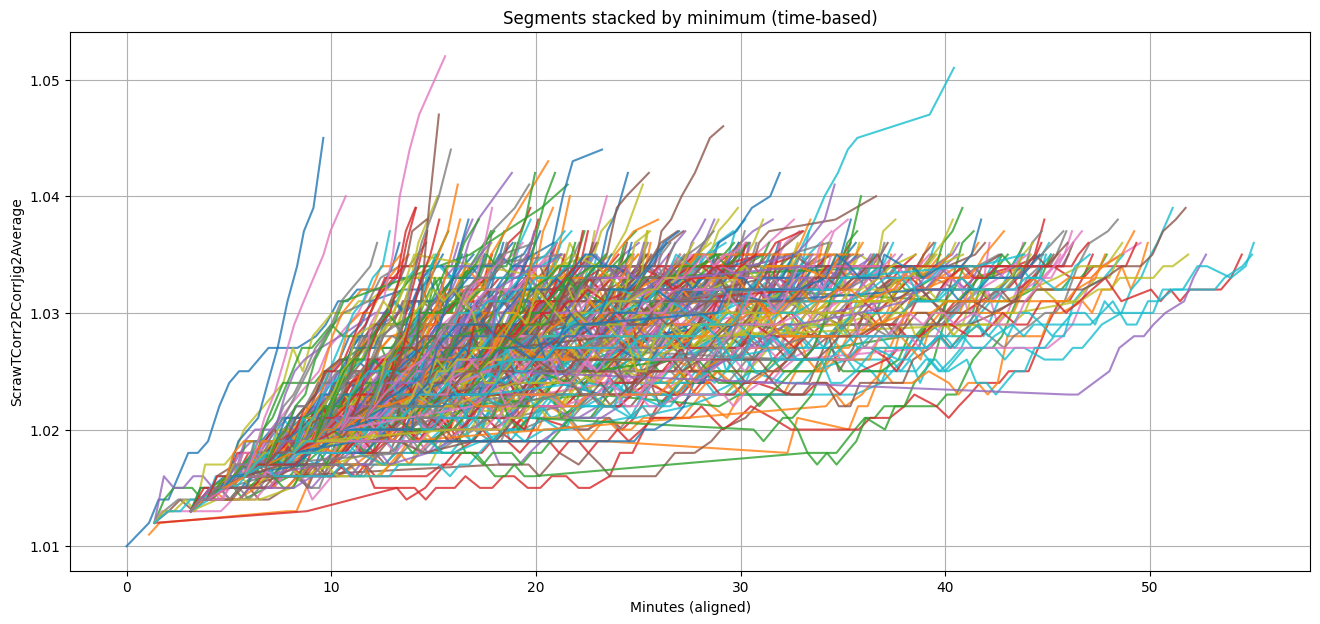

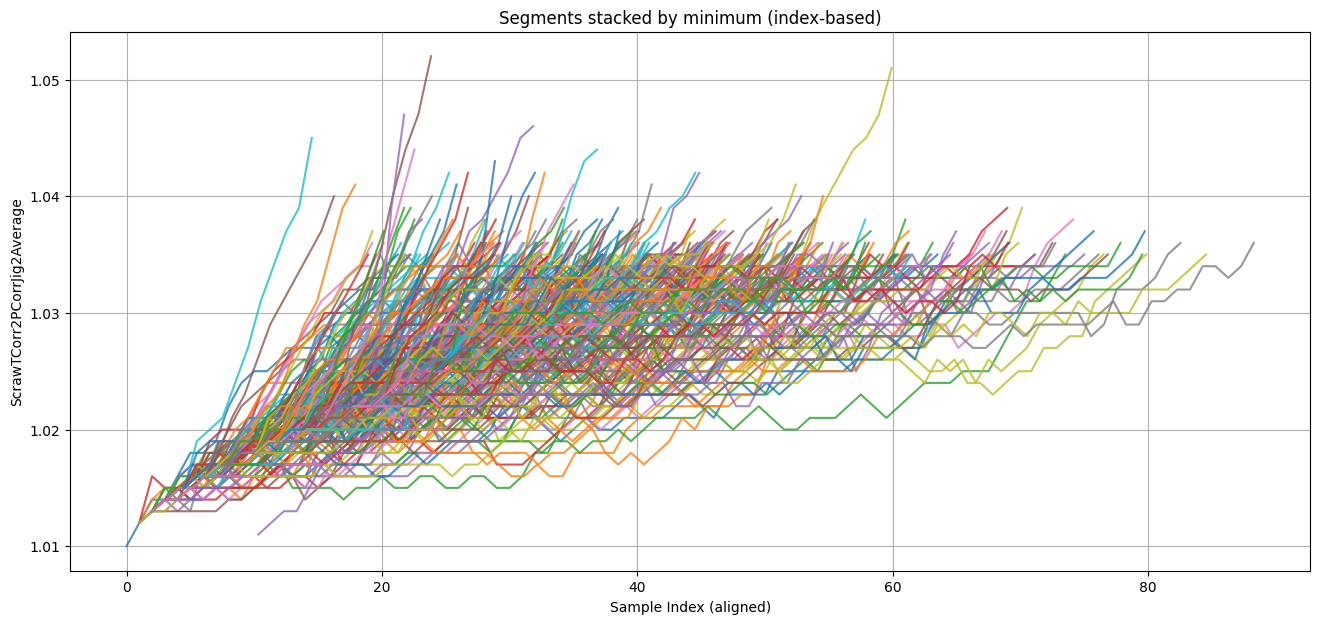

Št. constant-slope podsegmentov: 64


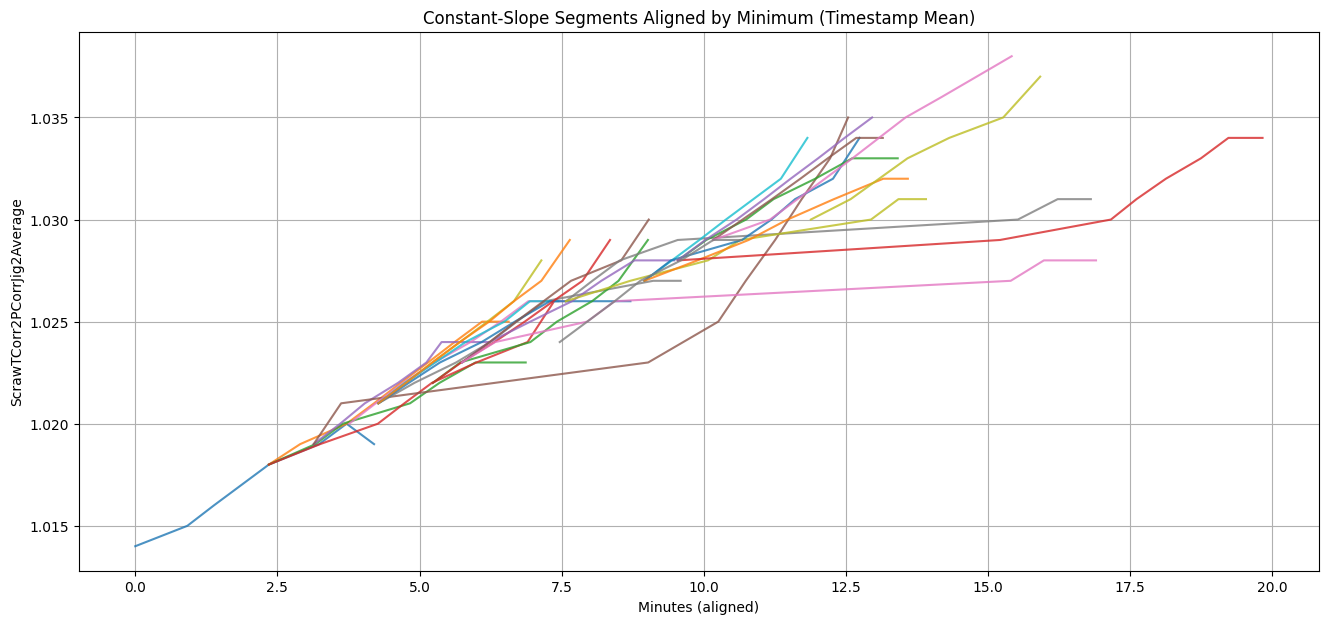

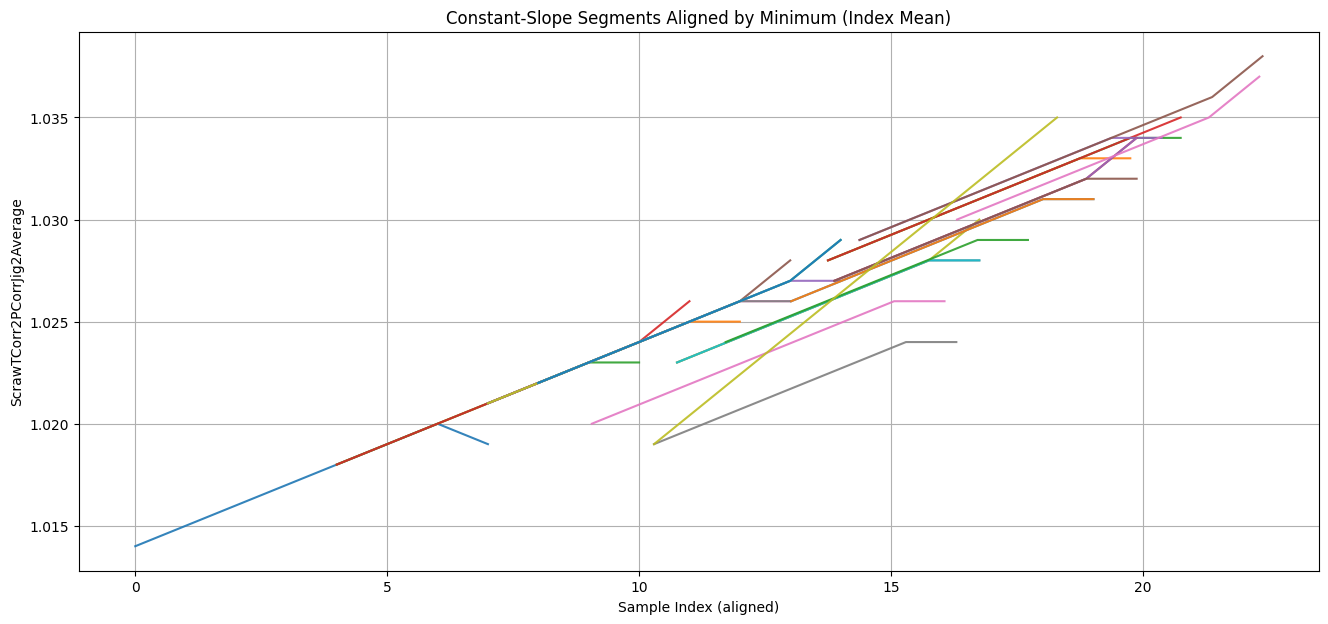

Št. constant segmentov (veljavnih): 29
Povprečen slope [vrednost/meritev]: 0.0010073891625616074
Median slope     [vrednost/meritev]: 0.0009166666666666836

Za current_value=1.025:
  Po POVPREČJU slope: threshold čez ~9.9 meritev
  Po MEDIAN slope   : threshold čez ~10.9 meritev


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 0) OSNOVNE PREDPOSTAVKE
# ==============================

VALUE_COL = "ScrawTCorr2PCorrJig2Average"
TIME_COL  = "Timestamp"
THRESHOLD = 1.035


# ==============================
# 1) SEGMENTIRANJE: min -> peak > threshold
# ==============================

def extract_segments(
    df,
    value_col=VALUE_COL,
    timestamp_col=TIME_COL,
    threshold=THRESHOLD,
    smooth_window_points=5,
    max_segment_minutes=45,
    min_points=5
):
    """
    Najde segmente (min -> peak), kjer zglajena vrednost preseže threshold,
    brez overlapa med segmenti.

    - glajenje samo za min/max (rolling median)
    - min = zadnji globalni minimum znotraj [mi, mj]
    - max = prvi globalni maximum znotraj [min_idx, mj]
    - samo segmenti z vsaj min_points točkami
    """

    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    df = df.sort_values(timestamp_col).reset_index(drop=True)

    # 1. glajenje
    df["value_smooth"] = (
        df[value_col]
        .rolling(window=smooth_window_points, center=True, min_periods=1)
        .median()
    )

    v_smooth = df["value_smooth"].to_numpy()
    n = len(v_smooth)

    # 2. lokalni min/max preko odvoda
    d = np.diff(v_smooth)
    min_idx = []
    max_idx = []

    for i in range(1, n-1):
        prev_d = d[i-1]
        next_d = d[i]

        if prev_d < 0 and next_d >= 0:
            min_idx.append(i)
        if prev_d > 0 and next_d <= 0:
            max_idx.append(i)

    max_duration = pd.Timedelta(minutes=max_segment_minutes)
    segments = []
    last_segment_end_time = None
    max_ptr = 0

    # 3. min -> najbližji peak nad threshold, brez overlapa
    for mi in min_idx:
        t_min_original = df.loc[mi, timestamp_col]

        if last_segment_end_time is not None and t_min_original <= last_segment_end_time:
            continue

        # premaknemo kazalec po maksimumih
        while max_ptr < len(max_idx) and max_idx[max_ptr] <= mi:
            max_ptr += 1

        chosen_mj = None
        k = max_ptr

        while k < len(max_idx):
            mj = max_idx[k]
            t_max_original = df.loc[mj, timestamp_col]

            if t_max_original - t_min_original > max_duration:
                break

            if v_smooth[mj] >= threshold:
                chosen_mj = mj
                max_ptr = k + 1
                break

            k += 1

        if chosen_mj is None:
            continue

        # 4. znotraj [mi, chosen_mj] poišči ZADNJI min in PRVI max po tem min
        start_idx_raw = mi
        end_idx_raw = chosen_mj

        seg_slice_full = df.loc[start_idx_raw:end_idx_raw]

        # zadnji minimum (raw)
        min_val = seg_slice_full[value_col].min()
        min_rows = seg_slice_full[seg_slice_full[value_col] == min_val]
        start_idx = int(min_rows.index[-1])

        # prvi maximum po tem min (raw)
        seg_slice = df.loc[start_idx:end_idx_raw]
        max_val = seg_slice[value_col].max()
        max_rows = seg_slice[seg_slice[value_col] == max_val]
        end_idx = int(max_rows.index[0])

        t_min = df.loc[start_idx, timestamp_col]
        t_max = df.loc[end_idx,   timestamp_col]

        # check duration & min_points
        if t_max - t_min > max_duration:
            continue

        num_points = end_idx - start_idx + 1
        if num_points < min_points:
            continue

        duration_min = (t_max - t_min).total_seconds() / 60.0

        seg = {
            "segment_id": len(segments),
            "start_idx": start_idx,
            "end_idx": end_idx,
            "segment_start": t_min,
            "segment_end": t_max,
            "duration_min": duration_min,
            "num_points": num_points,
        }
        segments.append(seg)

        last_segment_end_time = t_max

    return pd.DataFrame(segments)


def get_segment_df(df, seg_row, timestamp_col=TIME_COL):
    df = df.sort_values(timestamp_col).reset_index(drop=True)
    return df.loc[seg_row["start_idx"]:seg_row["end_idx"]].copy()


# ==============================
# 2) PLOT: osnovni segmenti stacked po min (čas & index)
# ==============================

def plot_segments_min_stacked_by_timestamp(df, segments_df,
                                           value_col=VALUE_COL,
                                           timestamp_col=TIME_COL):
    """
    Tvoja logika stackanja po minimumu z mean(timestamp) kot sidrom.
    """
    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    df = df.sort_values(timestamp_col).reset_index(drop=True)

    segments = []
    for _, row in segments_df.iterrows():
        seg = df.loc[row["start_idx"]:row["end_idx"]].copy()
        seg[timestamp_col] = pd.to_datetime(seg[timestamp_col])

        t0 = seg[timestamp_col].iloc[0]
        seg["t_rel"] = (seg[timestamp_col] - t0).dt.total_seconds() / 60.0

        y = seg[value_col].to_numpy().astype(float)
        t_rel = seg["t_rel"].to_numpy()

        min_val = y.min()
        min_idx = int(np.argmin(y))
        t_rel_min = float(t_rel[min_idx])

        segments.append({
            "y": y,
            "t_rel": t_rel,
            "min_val": min_val,
            "t_rel_min": t_rel_min
        })

    segments.sort(key=lambda s: s["min_val"])
    unique_mins = sorted(set(s["min_val"] for s in segments))

    drawn = []
    plt.figure(figsize=(16, 7))

    for minseg in unique_mins:
        group = [s for s in segments if s["min_val"] == minseg]

        if not drawn:
            # prva skupina
            for s in group:
                x_aligned = s["t_rel"]
                plt.plot(x_aligned, s["y"], alpha=0.8)
                drawn.append({"y": s["y"], "x": x_aligned})
        else:
            # poišči čas, ko prejšnji dosežejo minseg
            crossing_times = []
            for old in drawn:
                y_old, x_old = old["y"], old["x"]
                mask = y_old >= minseg
                if np.any(mask):
                    crossing_times.append(float(x_old[np.argmax(mask)]))

            if crossing_times:
                anchor = float(np.mean(crossing_times))
            else:
                anchor = max(old["x"][-1] for old in drawn)

            for s in group:
                shift = anchor - s["t_rel_min"]
                x_aligned = s["t_rel"] + shift
                plt.plot(x_aligned, s["y"], alpha=0.8)
                drawn.append({"y": s["y"], "x": x_aligned})

    plt.title("Segments stacked by minimum (time-based)")
    plt.xlabel("Minutes (aligned)")
    plt.ylabel(value_col)
    plt.grid(True)
    plt.show()


def plot_segments_min_stacked_by_index(df, segments_df,
                                       value_col=VALUE_COL):
    """
    Enako stackanje, ampak po sample indexu namesto časa.
    """
    segments = []
    for _, row in segments_df.iterrows():
        seg = df.loc[row["start_idx"]:row["end_idx"]].copy()

        y = seg[value_col].to_numpy().astype(float)
        t_rel = np.arange(len(y))

        min_val = y.min()
        min_idx = int(np.argmin(y))
        t_rel_min = float(min_idx)

        segments.append({
            "y": y,
            "t_rel": t_rel,
            "min_val": min_val,
            "t_rel_min": t_rel_min
        })

    segments.sort(key=lambda s: s["min_val"])
    unique_mins = sorted(set(s["min_val"] for s in segments))

    drawn = []
    plt.figure(figsize=(16, 7))

    for minseg in unique_mins:
        group = [s for s in segments if s["min_val"] == minseg]

        if not drawn:
            for s in group:
                x_aligned = s["t_rel"]
                plt.plot(x_aligned, s["y"], alpha=0.8)
                drawn.append({"y": s["y"], "x": x_aligned})
        else:
            crossing = []
            for old in drawn:
                y_old, x_old = old["y"], old["x"]
                mask = y_old >= minseg
                if np.any(mask):
                    crossing.append(float(x_old[np.argmax(mask)]))

            if crossing:
                anchor = float(np.mean(crossing))
            else:
                anchor = max(old["x"][-1] for old in drawn)

            for s in group:
                shift = anchor - s["t_rel_min"]
                x_aligned = s["t_rel"] + shift
                plt.plot(x_aligned, s["y"], alpha=0.8)
                drawn.append({"y": s["y"], "x": x_aligned})

    plt.title("Segments stacked by minimum (index-based)")
    plt.xlabel("Sample Index (aligned)")
    plt.ylabel(value_col)
    plt.grid(True)
    plt.show()


# ==============================
# 3) CONSTANT-SLOPE PODSEGMENTI
# ==============================

def extract_constant_slope_segments(seg_df,
                                    value_col=VALUE_COL,
                                    min_slope=0.00005,
                                    max_slope_std=0.00005,
                                    min_len=6):
    """
    Iz segmenta izlušči podsegmente z približno konstantnim, pozitivnim naklonom.
    """
    seg_df = seg_df.copy()
    y = seg_df[value_col].to_numpy().astype(float)
    slope = np.diff(y)

    subsegments = []
    start = 0

    for i in range(1, len(slope)):
        window = slope[start:i]

        if (np.any(window < 0) or
            np.mean(window) < min_slope or
            np.std(window) > max_slope_std):

            if (i - start) >= min_len:
                subsegments.append(seg_df.iloc[start:i+1])

            start = i

    if (len(slope) - start) >= min_len:
        subsegments.append(seg_df.iloc[start:len(seg_df)])

    return subsegments


def get_all_constant_segments(df, segments_df,
                              value_col=VALUE_COL,
                              timestamp_col=TIME_COL,
                              **kwargs):
    """
    Za vsakega iz segments_df vrne constant-slope podsegmente.
    """
    constant_segments = []

    for _, row in segments_df.iterrows():
        seg_df = get_segment_df(df, row, timestamp_col=timestamp_col)
        subs = extract_constant_slope_segments(seg_df,
                                               value_col=value_col,
                                               **kwargs)
        constant_segments.extend(subs)

    return constant_segments


# ==============================
# 4) PLOT: constant-slope stacked (čas & index)
# ==============================

def plot_constant_segments_stacked_by_timestamp(constant_segments,
                                                value_col=VALUE_COL,
                                                timestamp_col=TIME_COL):
    segs = []
    for seg in constant_segments:
        s = seg.copy()
        s[timestamp_col] = pd.to_datetime(s[timestamp_col])
        t0 = s[timestamp_col].iloc[0]
        t_rel = (s[timestamp_col] - t0).dt.total_seconds() / 60.0
        y = s[value_col].to_numpy().astype(float)

        min_val = y.min()
        min_idx = int(np.argmin(y))
        t_rel_min = float(t_rel.iloc[min_idx])

        segs.append({
            "y": y,
            "t_rel": t_rel.to_numpy(),
            "min_val": min_val,
            "t_rel_min": t_rel_min
        })

    if not segs:
        print("Ni constant-slope segmentov.")
        return

    segs.sort(key=lambda s: s["min_val"])
    unique_mins = sorted(set(s["min_val"] for s in segs))

    drawn = []
    plt.figure(figsize=(16, 7))

    for minseg in unique_mins:
        group = [s for s in segs if s["min_val"] == minseg]

        if not drawn:
            for s in group:
                x_aligned = s["t_rel"]
                plt.plot(x_aligned, s["y"], alpha=0.8)
                drawn.append({"y": s["y"], "x": x_aligned})
        else:
            crossing = []
            for old in drawn:
                y_old, x_old = old["y"], old["x"]
                mask = y_old >= minseg
                if np.any(mask):
                    crossing.append(float(x_old[np.argmax(mask)]))

            if crossing:
                anchor = float(np.mean(crossing))
            else:
                anchor = max(old["x"][-1] for old in drawn)

            for s in group:
                shift = anchor - s["t_rel_min"]
                x_aligned = s["t_rel"] + shift
                plt.plot(x_aligned, s["y"], alpha=0.8)
                drawn.append({"y": s["y"], "x": x_aligned})

    plt.title("Constant-Slope Segments Aligned by Minimum (Timestamp Mean)")
    plt.xlabel("Minutes (aligned)")
    plt.ylabel(value_col)
    plt.grid(True)
    plt.show()


def plot_constant_segments_stacked_by_index(constant_segments,
                                            value_col=VALUE_COL):
    segs = []
    for seg in constant_segments:
        y = seg[value_col].to_numpy().astype(float)
        t_rel = np.arange(len(y))
        min_val = y.min()
        min_idx = int(np.argmin(y))
        t_rel_min = float(min_idx)

        segs.append({
            "y": y,
            "t_rel": t_rel,
            "min_val": min_val,
            "t_rel_min": t_rel_min
        })

    if not segs:
        print("Ni constant-slope segmentov.")
        return

    segs.sort(key=lambda s: s["min_val"])
    unique_mins = sorted(set(s["min_val"] for s in segs))

    drawn = []
    plt.figure(figsize=(16, 7))

    for minseg in unique_mins:
        group = [s for s in segs if s["min_val"] == minseg]

        if not drawn:
            for s in group:
                x_aligned = s["t_rel"]
                plt.plot(x_aligned, s["y"], alpha=0.9)
                drawn.append({"y": s["y"], "x": x_aligned})
        else:
            crossing = []
            for old in drawn:
                y_old, x_old = old["y"], old["x"]
                mask = y_old >= minseg
                if np.any(mask):
                    crossing.append(float(x_old[np.argmax(mask)]))

            if crossing:
                anchor = float(np.mean(crossing))
            else:
                anchor = max(old["x"][-1] for old in drawn)

            for s in group:
                shift = anchor - s["t_rel_min"]
                x_aligned = s["t_rel"] + shift
                plt.plot(x_aligned, s["y"], alpha=0.9)
                drawn.append({"y": s["y"], "x": x_aligned})

    plt.title("Constant-Slope Segments Aligned by Minimum (Index Mean)")
    plt.xlabel("Sample Index (aligned)")
    plt.ylabel(value_col)
    plt.grid(True)
    plt.show()


# ==============================
# 5) GLOBALNI SLOPE + NAPOVED ŠT. MERITEV DO THRESHOLDA
# ==============================

def global_slope_from_constant_segments(constant_segments,
                                        value_col=VALUE_COL):
    """
    Vrne:
      - mean_slope  (povprečen slope po indeksu)
      - median_slope
      - slopes: array vseh veljavnih slope-ov
    """
    raw_slopes = []

    for seg in constant_segments:
        y = seg[value_col].to_numpy().astype(float)
        x = np.arange(len(y))

        if len(x) < 2:
            continue

        a, b = np.polyfit(x, y, deg=1)
        raw_slopes.append(a)

    raw_slopes = np.array(raw_slopes, dtype=float)
    mask = np.isfinite(raw_slopes) & (raw_slopes > 0)
    slopes = raw_slopes[mask]

    if len(slopes) == 0:
        return None, None, slopes

    mean_slope = float(slopes.mean())
    median_slope = float(np.median(slopes))

    return mean_slope, median_slope, slopes


def predict_samples_to_threshold_global(current_value,
                                        threshold,
                                        slope_per_sample):
    """
    Vrne koliko meritev (sample-ov) manjka do thresholda,
    glede na podan slope_per_sample [vrednost / meritev].
    """
    current_value = float(current_value)
    threshold = float(threshold)

    if slope_per_sample is None or slope_per_sample <= 0:
        return None

    delta = threshold - current_value
    if delta <= 0:
        return 0

    return float(delta / slope_per_sample)


# ==============================
# 6) PRIMER UPORABE CELEGA PIPELINE-A
# ==============================

# 1) Izlušči segmente
segments_df = extract_segments(df, value_col=VALUE_COL, timestamp_col=TIME_COL,
                               threshold=THRESHOLD)

print("Št. segmentov:", len(segments_df))
print(segments_df.head())

# 2) Ploti osnovne segmente (čas & index)
plot_segments_min_stacked_by_timestamp(df, segments_df,
                                       value_col=VALUE_COL,
                                       timestamp_col=TIME_COL)

plot_segments_min_stacked_by_index(df, segments_df,
                                   value_col=VALUE_COL)

# 3) Constant-slope podsegmenti
constant_segments = get_all_constant_segments(df, segments_df,
                                              value_col=VALUE_COL,
                                              timestamp_col=TIME_COL)

print("Št. constant-slope podsegmentov:", len(constant_segments))

# 4) Ploti constant-slope (čas & index)
plot_constant_segments_stacked_by_timestamp(constant_segments,
                                            value_col=VALUE_COL,
                                            timestamp_col=TIME_COL)

plot_constant_segments_stacked_by_index(constant_segments,
                                        value_col=VALUE_COL)

# 5) Globalni slope + napoved za neko trenutno vrednost
mean_slope, median_slope, slopes = global_slope_from_constant_segments(
    constant_segments,
    value_col=VALUE_COL
)

print("Št. constant segmentov (veljavnih):", len(slopes))
print("Povprečen slope [vrednost/meritev]:", mean_slope)
print("Median slope     [vrednost/meritev]:", median_slope)

# primer napovedi: trenutna vrednost 1.025
current_value = 1.025
n_mean   = predict_samples_to_threshold_global(current_value, THRESHOLD, mean_slope)
n_median = predict_samples_to_threshold_global(current_value, THRESHOLD, median_slope)

print(f"\nZa current_value={current_value}:")
print(f"  Po POVPREČJU slope: threshold čez ~{n_mean:.1f} meritev")
print(f"  Po MEDIAN slope   : threshold čez ~{n_median:.1f} meritev")
